# Controlled buffer-window sensitivity
**Provenance correction (22 September):** Natalie’s notebooks perform buffer subtraction on the HDF5 input profiles. Both AA_082024.ipynb and AA_052026.ipynb load AA_052026.hdf5 and report buffer frames24–70; the primary WT analysis reports220–236. Earlier claims that the needed pre-subtraction profiles were absent, or that our HDF5-based subtraction was necessarily only a residual correction, were incorrect. The HDF5-based calculations already read `profiles` and subtract their chosen buffer once, so this correction does not itself change their numerical output. Original exported DAT curves are a later processing stage and must not be subtracted again. The new controlled test is in [09_buffer_window_sensitivity.ipynb](09_buffer_window_sensitivity.ipynb).

## Question and fixed choices
Subtract the mean of **25–35**, **60–70**, or **210–220** (11 frames each, inclusive and zero-based) directly from the input profiles. Include Natalie’s buffer windows as references. Do not add a subsequent baseline correction. The AA reference is therefore her buffer-subtraction step, not her entire later endpoint-baseline workflow.

Keep protein windows fixed: WT selected159–175, leading161–165, apex165–169; AA selected169–188, leading165–169, apex175–179. Keep EFA ROIs, two-component supports, and q range unchanged. Conventional fits use0.012–0.030Å⁻¹; extended fits use0.012–0.055Å⁻¹. Report qRg validity flags; additional adaptive extended fits are retained in JSON. EFA-other common-range fits may be unsupported because the range is too wide or the curve is nonphysical; they are not species assignments.

For each sample,100 identical input-frame perturbations are propagated through all four subtraction choices. Shared-buffer covariance and overlapping frames are retained algebraically. EFA is rerun on each draw. Failed rotations remain failures; intervals for EFA are conditional on successful rotations and fixed supports. BIFT is rerun for selected averages and successful EFA-main estimates with identical q/Dmax/regularization search settings and80 local parameter samples. This does not supply between-experiment uncertainty.

## Findings
The selected-average extended Rg is **WT28.39/28.17/26.60Å** and **AA32.09/32.25/31.98Å** for25–35/60–70/210–220. Thus AA remains larger, but WT≈26Å is not invariant to buffer selection. Conventional Guinier and P(r) show additional method sensitivity and must not be pooled as interchangeable Rg estimates.

AA210–220 fails stationarity (maximum band slope≈7 standard errors); it is a deliberately tested, questionable buffer choice, not a recommended clean buffer. The AA60–70 nominal two-component EFA rotation fails. AA25–35 converges on only63/100 perturbations, versus100/100 for WT. These failures argue against relying on AA forced two-component extraction as the primary size estimate.


In [1]:
from pathlib import Path
import sys,json
import numpy as np
from IPython.display import display,Markdown
ROOT=Path.cwd();sys.path.insert(0,str(ROOT/'analysis'))
import test_buffer_windows as test
%matplotlib inline


## Source evidence and single-subtraction validation

In [2]:
print((test.OUT/'provenance_validation.json').read_text())
for item in json.loads((test.OUT/'notebook_provenance.json').read_text()):
    print(item['notebook'])
    for cell in item['cells']:
        print(cell['source']);print(cell['output'])

{
  "WT_frame180_input_minus_220_236_matches_export_max_abs_difference": 3.2539260175212803e-09,
  "pre_subtraction_input_profiles_available": true,
  "buffer_subtraction_count_in_new_test": 1,
  "AA_notebook_input": "data/AA_052026.hdf5",
  "AA_notebook_buffer": [
    24,
    70
  ]
}
AA_082024.ipynb
AA_h5='./data/AA_052026.h5'
AA_hdf5='./data/AA_052026.hdf5'


[]
#Define a list of series filenames to load
series_names = [AA_hdf5]

#Load the series
series = raw.load_series(series_names)
print(series)
[]
#Set buffer range
success, region_start, region_end = raw.find_buffer_range(my_series)
print(f"Buffer range found: {success}, start: {region_start}, end: {region_end}")
    
(sub_profiles, rg, rger, i0, i0er, vcmw, vcmwer,
    vpmw) = raw.set_buffer_range(my_series, [[region_start, region_end]])

['Buffer range found: True, start: 24, end: 70\n']
# Baseline Correction
# Validate baseline range
(lin_valid, lin_valid_results, lin_similarity_results, lin_svd_results,
    lin_intI_results,

## Reproduce the controlled experiment
The executed results are included. Set RECOMPUTE=True to rerun all frame perturbations, EFA rotations and BIFT fits; viewing the notebook defaults to reading those saved results.

In [3]:
RECOMPUTE=False
if RECOMPUTE:
    rows=test.run(nboot=100,do_bift=True)
else:
    rows=json.loads((test.OUT/'results.json').read_text())
print(len(rows),'curve results loaded')

38 curve results loaded


## Buffer-region diagnostics
Passing this test only indicates time stability; it cannot rule out stationary sample contamination. Failed210–220 AA is not a validated buffer.

WT_092025 early_25_35 max slope z: 1.07 half-window discrepancy: 0.67 stationary: True
WT_092025 early_60_70 max slope z: 1.12 half-window discrepancy: 0.76 stationary: True
WT_092025 post_210_220 max slope z: 1.26 half-window discrepancy: 0.84 stationary: True
WT_092025 Natalie_buffer_reference max slope z: 1.24 half-window discrepancy: 0.68 stationary: True
AA_052026 early_25_35 max slope z: 0.64 half-window discrepancy: 0.51 stationary: True
AA_052026 early_60_70 max slope z: 0.93 half-window discrepancy: 0.54 stationary: True
AA_052026 post_210_220 max slope z: 7.01 half-window discrepancy: 1.27 stationary: False
AA_052026 Natalie_buffer_reference max slope z: 1.78 half-window discrepancy: 0.6 stationary: True


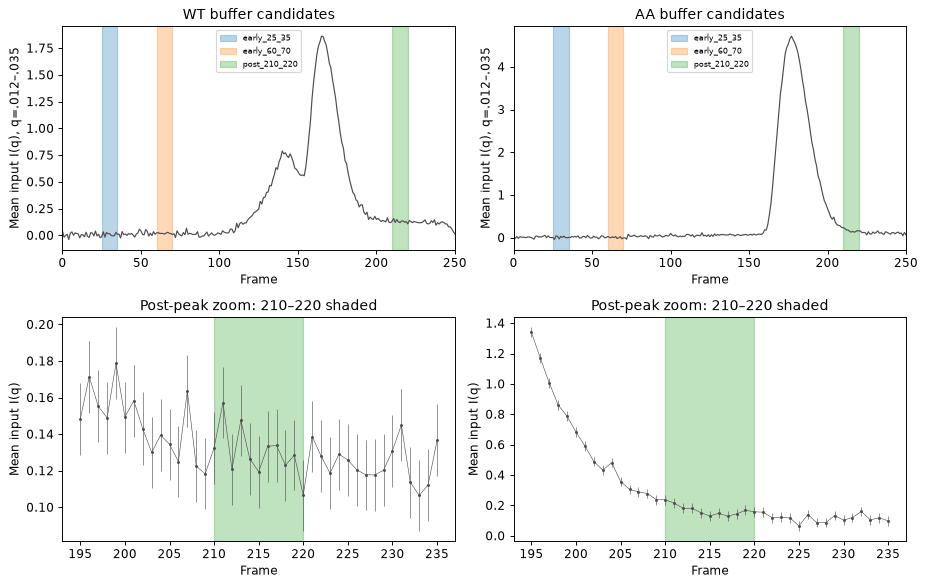

In [4]:
for row in json.loads((test.OUT/'anchor_checks.json').read_text()):
    print(row['sample'],row['buffer'],'max slope z:',round(row['max_band_slope_z'],2),'half-window discrepancy:',round(row['half_profile_ms'],2),'stationary:',row['passes'])
test.show_anchors()

## I(q), fits, Kratky and P(r) comparisons

|Sample|Buffer frames|Curve|Conventional Rg|Extended Rg|Extended95%|BIFT Rg|
|---|---|---|---:|---:|---|---:|
|WT|[25, 35]|selected_average|31.33|28.39|[27.745736209839826, 28.899437932970642]|29.4|
|WT|[25, 35]|leading_5|32.54|28.28|[27.450429616125646, 28.84370263729661]|None|
|WT|[25, 35]|apex_5|29.85|27.95|[27.227592068891518, 28.57345421683153]|None|
|WT|[25, 35]|EFA_main|31.44|28.24|[27.46750038848529, 28.717070109147162]|29.27|
|WT|[60, 70]|selected_average|30.76|28.17|[27.666387481644488, 28.63177006976655]|29.09|
|WT|[60, 70]|leading_5|32.09|28.09|[27.21783455460421, 28.83582027821807]|None|
|WT|[60, 70]|apex_5|29.29|27.77|[27.031179765710927, 28.325952069222826]|None|
|WT|[60, 70]|EFA_main|30.79|28.03|[27.411896373225133, 28.462941465314035]|28.98|
|WT|[210, 220]|selected_average|26.15|26.60|[26.092769081845525, 27.041878711927996]|27.26|
|WT|[210, 220]|leading_5|28.10|26.65|[25.893744072693217, 27.404197405988697]|None|
|WT|[210, 220]|apex_5|24.97|26.38|[25.790021029425937, 27.025742763797556]|None|
|WT|[210, 220]|EFA_main|24.85|25.86|[25.3081792301317, 26.36416550833564]|26.61|
|WT|[220, 236]|selected_average|27.44|26.58|[26.04652659901685, 27.07840376763647]|27.23|
|WT|[220, 236]|leading_5|29.25|26.63|[25.904010247910204, 27.322328404610673]|None|
|WT|[220, 236]|apex_5|26.18|26.36|[25.714516836427805, 27.032888016256667]|None|
|WT|[220, 236]|EFA_main|26.23|25.84|[25.32971509426973, 26.388057660972148]|26.54|
|AA|[25, 35]|selected_average|33.17|32.09|[31.829809810746283, 32.300326663781604]|35.91|
|AA|[25, 35]|leading_5|34.60|31.58|[30.818615239655923, 32.203143462120444]|None|
|AA|[25, 35]|apex_5|33.22|32.26|[31.933881526219952, 32.57971714982918]|None|
|AA|[25, 35]|EFA_main|34.58|32.32|[31.863417493789676, 32.69472264137096]|33.4|
|AA|[60, 70]|selected_average|32.95|32.25|[31.975471459355504, 32.59563346934384]|35.71|
|AA|[60, 70]|leading_5|34.23|31.90|[31.13579974920211, 32.53388938593714]|None|
|AA|[60, 70]|apex_5|33.01|32.40|[32.07900942016853, 32.822867920354774]|None|
|AA|[210, 220]|selected_average|31.69|31.98|[31.642755516895626, 32.27238182379702]|32.61|
|AA|[210, 220]|leading_5|31.76|31.35|[30.36249554732828, 32.0357708942397]|None|
|AA|[210, 220]|apex_5|31.90|32.16|[31.767876438502544, 32.53877148949535]|None|
|AA|[210, 220]|EFA_main|30.60|31.54|[31.319563797694943, 32.34668849686829]|31.74|
|AA|[24, 70]|selected_average|32.96|32.19|[32.00065431094779, 32.422824798720804]|35.56|
|AA|[24, 70]|leading_5|34.16|31.75|[31.06297687500398, 32.28937096166004]|None|
|AA|[24, 70]|apex_5|33.01|32.34|[32.06814785878772, 32.658197312424605]|None|
|AA|[24, 70]|EFA_main|33.39|32.14|[31.85322406765601, 32.54849760511815]|33.34|


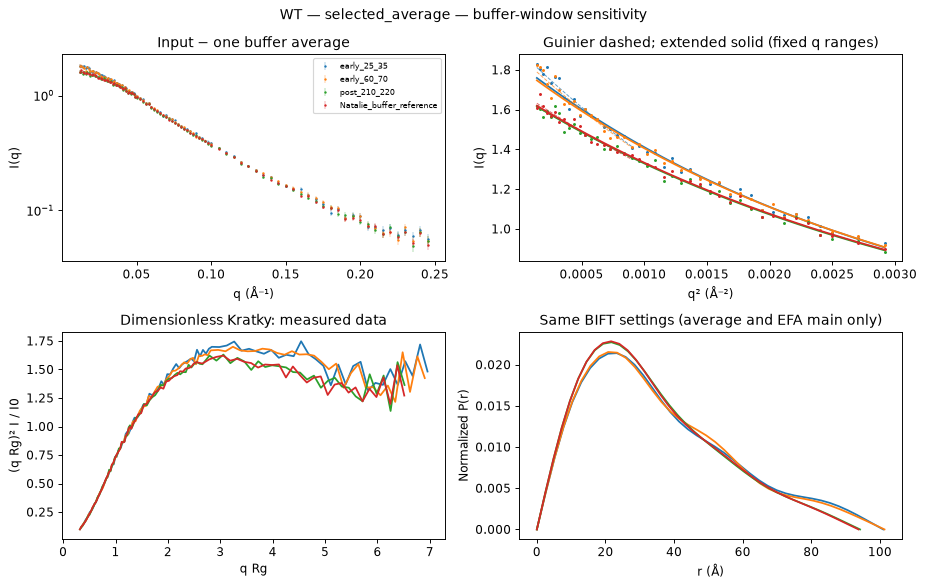

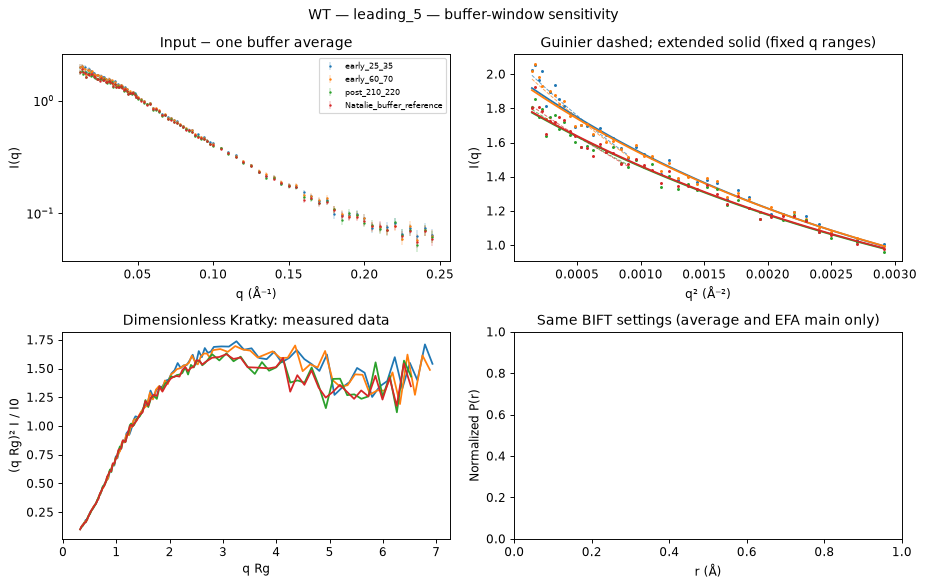

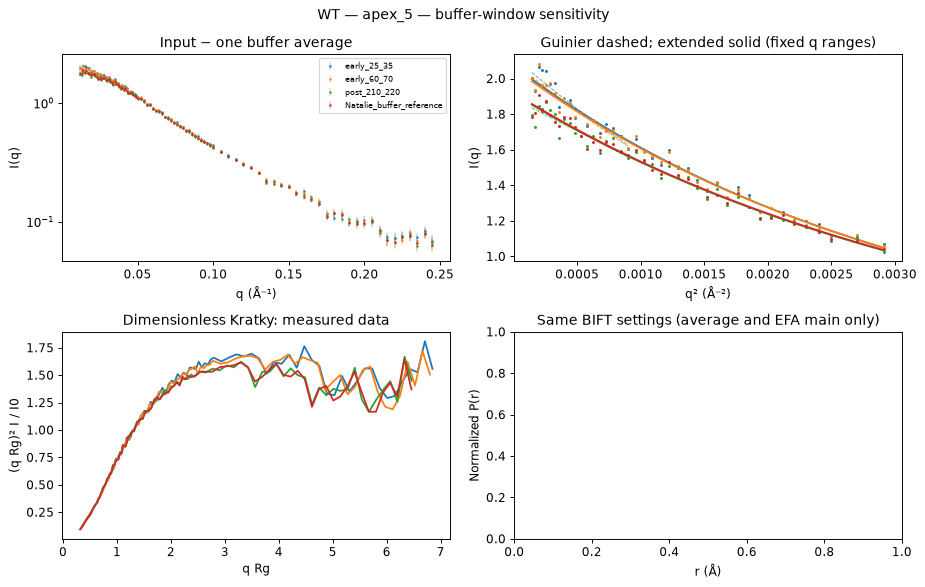

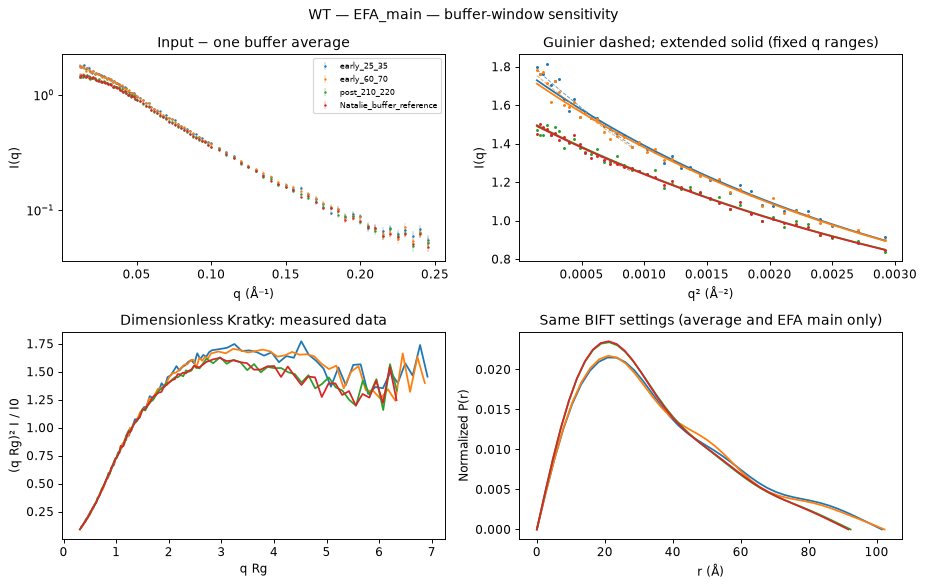

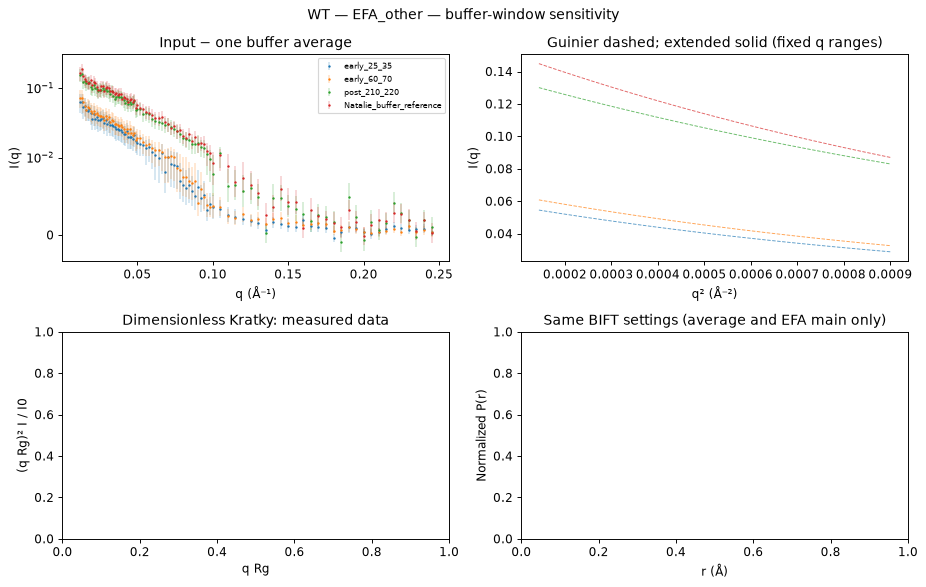

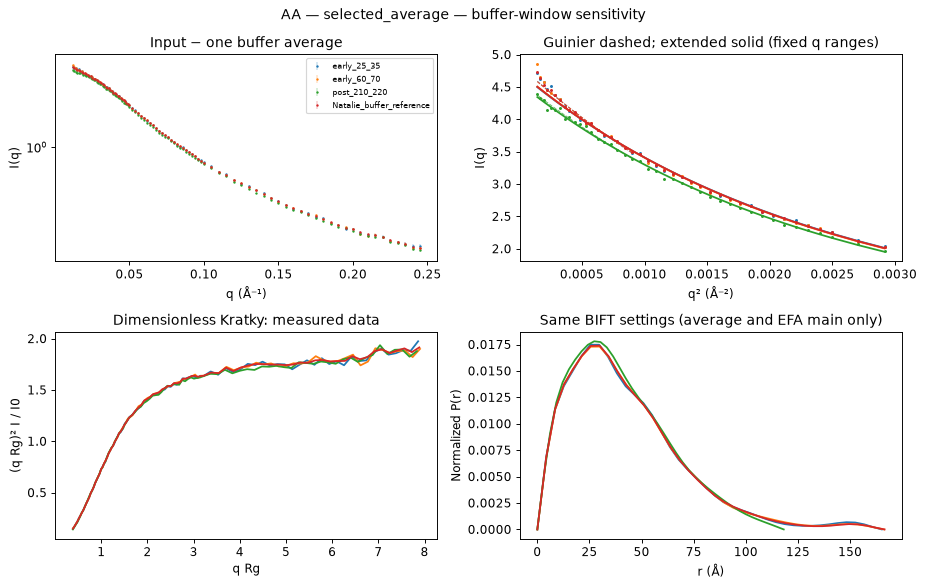

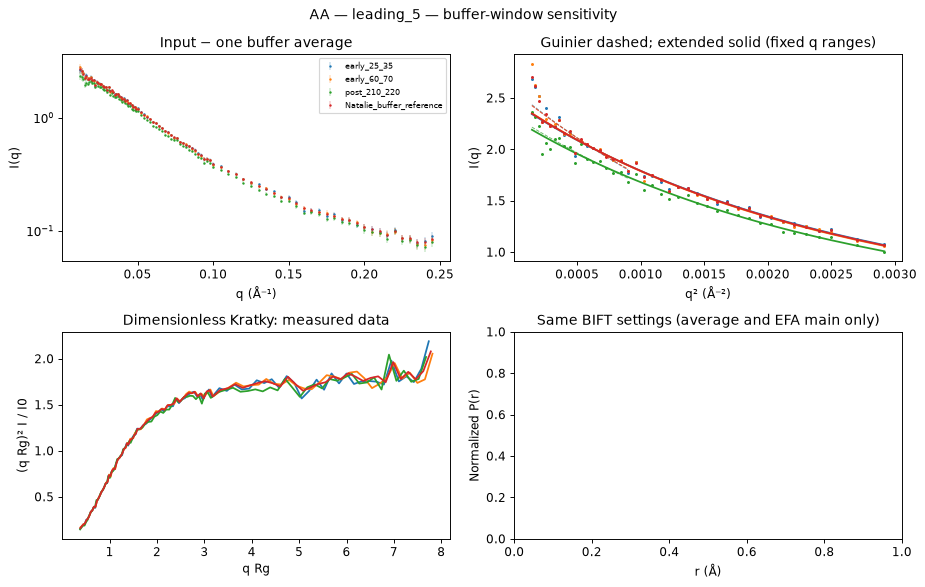

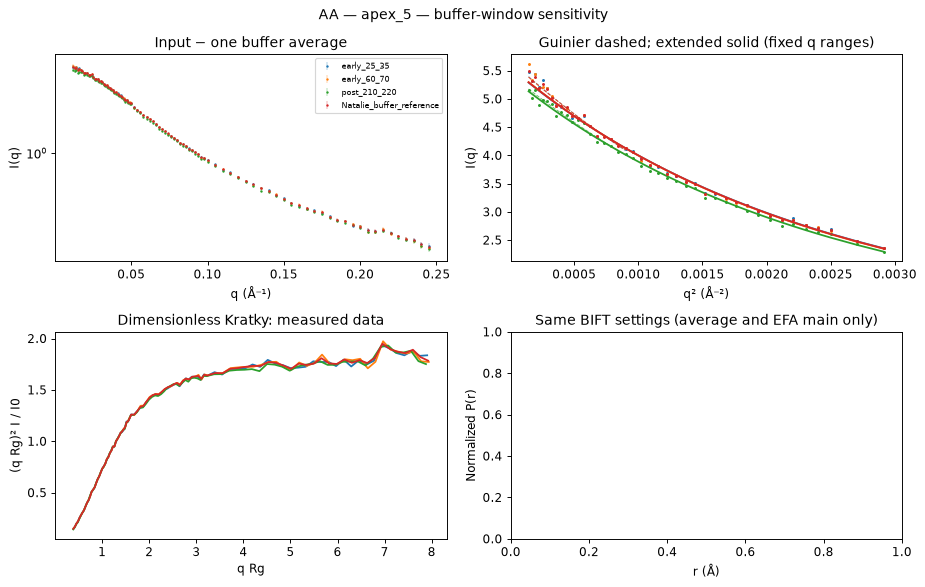

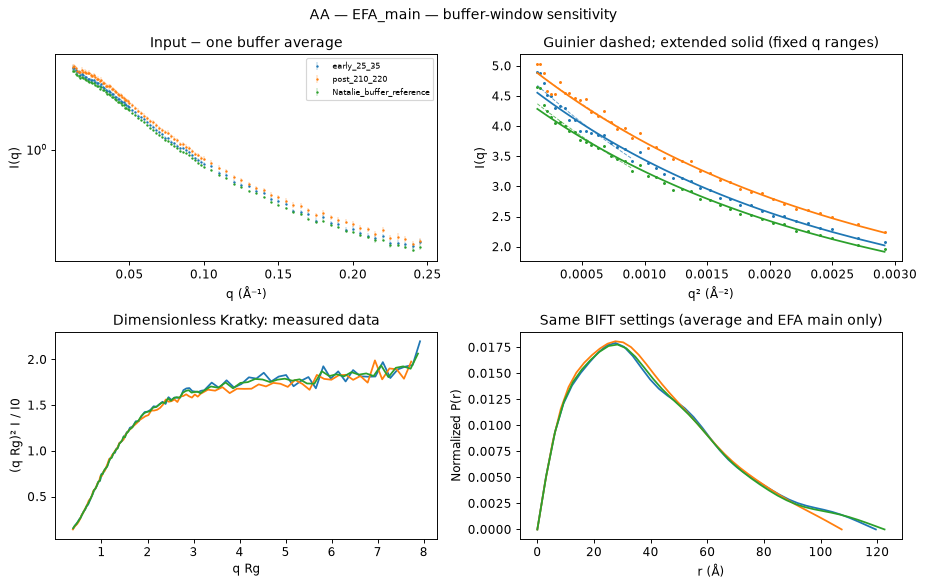

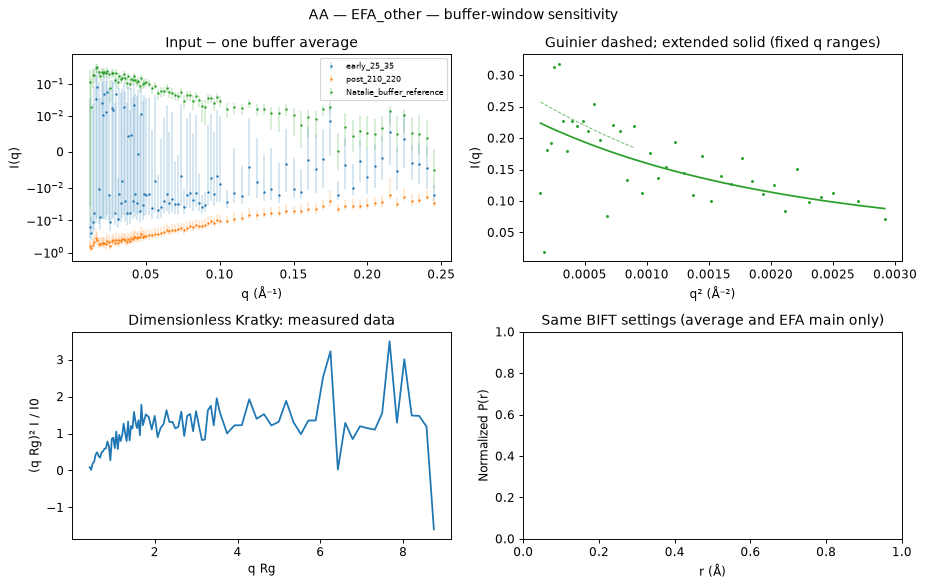

In [5]:
rows=test.show_results()

## EFA convergence and paired subtraction effects
A missing EFA curve is a failure, not a zero effect. EFA intervals exclude failed fits and must be interpreted with the success counts.

In [6]:
for sample in test.SPECS:
    for label in list(test.REQUESTED)+['Natalie_buffer_reference']:
        p=test.OUT/f'{sample}_{label}_propagation.npz';a=np.load(p)
        print(sample,label,'nominal converged:',len(a['C'])>0,'bootstrap:',np.all(np.isfinite(a['boot_main']),axis=1).sum(),'/',len(a['boot_main']))
for row in json.loads((test.OUT/'paired_differences.json').read_text()):
    if row['curve'] in ['selected_average','EFA_main']:print(row)

WT_092025 early_25_35 nominal converged: True bootstrap: 100 / 100
WT_092025 early_60_70 nominal converged: True bootstrap: 100 / 100
WT_092025 post_210_220 nominal converged: True bootstrap: 100 / 100
WT_092025 Natalie_buffer_reference nominal converged: True bootstrap: 100 / 100
AA_052026 early_25_35 nominal converged: True bootstrap: 63 / 100
AA_052026 early_60_70 nominal converged: False bootstrap: 77 / 100
AA_052026 post_210_220 nominal converged: True bootstrap: 92 / 100
AA_052026 Natalie_buffer_reference nominal converged: True bootstrap: 99 / 100
{'sample': 'WT_092025', 'buffer': 'early_25_35', 'curve': 'selected_average', 'reference': 'Natalie_buffer_reference', 'extended_delta95': [1.2300438721062972, 2.23493645506457], 'successful_pairs': 100}
{'sample': 'WT_092025', 'buffer': 'early_25_35', 'curve': 'EFA_main', 'reference': 'Natalie_buffer_reference', 'extended_delta95': [1.621783349666651, 2.855093585544166], 'successful_pairs': 100}
{'sample': 'WT_092025', 'buffer': 'earl

## AA minus WT under each subtraction
These paired-by-replicate calculations use independent WT/AA noise draws. They quantify conditional measurement uncertainty, not biological replicate variability.

In [7]:
sample_differences=test.compare_samples()
for row in sample_differences: print(row)

{'buffer': 'early_25_35', 'curve': 'selected_average', 'AA_minus_WT': 3.69704777592937, 'conditional95': [3.083596981414485, 4.412692884929742], 'valid_pairs': 100, 'note': 'Independent sample perturbations; not biological replicate variability. Natalie-reference buffers differ between samples.'}
{'buffer': 'early_25_35', 'curve': 'EFA_main', 'AA_minus_WT': 4.082969193978524, 'conditional95': [3.4610388354343637, 4.829130667154223], 'valid_pairs': 63, 'note': 'Independent sample perturbations; not biological replicate variability. Natalie-reference buffers differ between samples.'}
{'buffer': 'early_60_70', 'curve': 'selected_average', 'AA_minus_WT': 4.079513148741729, 'conditional95': [3.55590072175439, 4.713082068110607], 'valid_pairs': 100, 'note': 'Independent sample perturbations; not biological replicate variability. Natalie-reference buffers differ between samples.'}
{'buffer': 'post_210_220', 'curve': 'selected_average', 'AA_minus_WT': 5.381192432958997, 'conditional95': [4.718

## Conclusion
The original input profiles are available for independent buffer subtraction. Among the tested choices, the AA>WT size difference persists; the absolute WT Rg and the size of that difference depend on buffer selection and analysis method. Choose the buffer using physical sample-free regions and time stability, not a preferred Rg. Do not use the high-Rg shoulder as buffer. The210–220 AA result is a stress test because that interval is changing with time. Absolute publication values should carry the buffer/model sensitivity until a justified primary subtraction is selected.